In [1]:
!pip install astroML

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as s

In [3]:
from urllib.request import urlretrieve

In [5]:
urlretrieve("https://das.sdss.org/va/qsocat/dr7qso.dat", './drsqso.dat')

('./drsqso.dat', <http.client.HTTPMessage at 0x201fe618cd0>)

In [6]:
# There are 80 header lines, skip them. The redfshift is in column 3. 
#Careful that there's another z feature, but that refers to the SDSS z filter, not the redshift
z= np.loadtxt('dr7qso.dat',skiprows=80, usecols=3)

In [25]:
counts, bin_edges = np.histogram(z)
bincenters = bin_edges[]

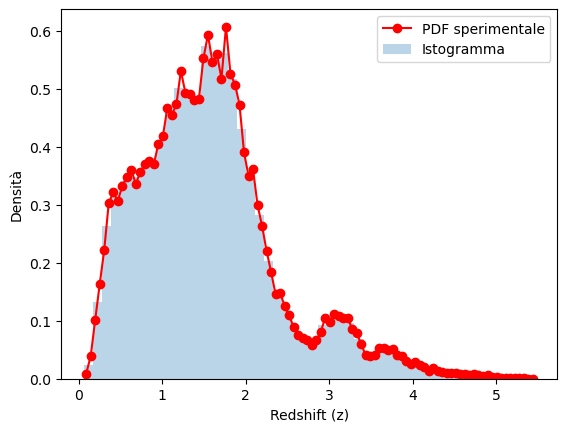

In [27]:
# Supponiamo che 'z' siano i tuoi dati dei Quasar
counts, bins = np.histogram(z, bins=100, density=True)

# Calcoliamo i centri dei bin
# (bordo_destro + bordo_sinistro) / 2
bin_centers = (bins[:-1] + bins[1:]) / 2

# Ora puoi plottare i punti e connetterli con una retta
plt.plot(bin_centers, counts, '-', marker='o', color='red', label='PDF sperimentale')
plt.hist(z, bins=50, density=True, alpha=0.3, label='Istogramma') # Per confronto
plt.xlabel('Redshift (z)')
plt.ylabel('Densità')
plt.legend()
plt.show()

In [17]:
def rejection_sampling(n_new_samples, z_min, z_max):
    samples = []
    # M must be higher than the peak of our KDE
    M = target_pdf(np.array([1.5])) * 1.2 
    
    while len(samples) < n_new_samples:
        # 1. Sample from proposal distribution g(x) ~ Uniform
        x_prop = np.random.uniform(z_min, z_max)
        # 2. Sample from Uniform(0, M*g(x))
        u = np.random.uniform(0, M)
        
        # 3. Accept/Reject
        if u < target_pdf(np.array([x_prop])):
            samples.append(x_prop)
            
    return np.array(samples)

z_upsampled_rejection = rejection_sampling(5000, z.min(), z.max())

KeyboardInterrupt: 

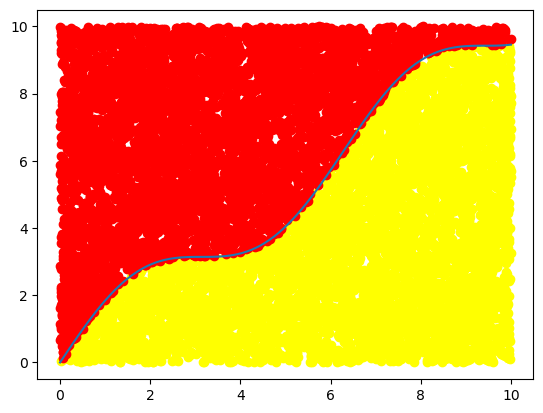

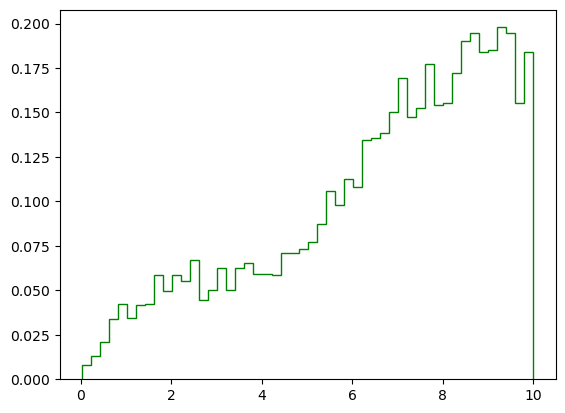

In [12]:
f = lambda x: x+np.sin(x)  # pause and look at how great lambda functions are! 

N=10000

xg = np.linspace(0,10,100)

plt.plot(xg,f(xg))


ymax = 10
x = np.random.uniform(0,10,N)
y = np.random.uniform(0,ymax,N)


plt.scatter(x[y<f(x)],y[y<f(x)],c='yellow')
plt.scatter(x[y>f(x)],y[y>f(x)],c='red')

plt.show()
goodpoints = x[y<f(x)]


plt.hist(goodpoints,bins=50,density=True,histtype='step',color='green');